<a href="https://colab.research.google.com/github/KarimBekhtiGalvao/Diffusion-Based-Generation/blob/main/Generation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Architecture from github

In [ ]:
import numpy as np

def _warmup_beta(beta_start, beta_end, num_diffusion_timesteps, warmup_frac):
  betas = beta_end * np.ones(num_diffusion_timesteps, dtype=np.float64)
  warmup_time = int(num_diffusion_timesteps * warmup_frac)
  betas[:warmup_time] = np.linspace(beta_start, beta_end, warmup_time, dtype=np.float64)
  return betas

def get_beta_schedule(beta_schedule, *, beta_start, beta_end, num_diffusion_timesteps):
  if beta_schedule == 'quad':
    betas = np.linspace(beta_start ** 0.5, beta_end ** 0.5, num_diffusion_timesteps, dtype=np.float64) ** 2
  elif beta_schedule == 'linear':
    betas = np.linspace(beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64)
  elif beta_schedule == 'warmup10':
    betas = _warmup_beta(beta_start, beta_end, num_diffusion_timesteps, 0.1)
  elif beta_schedule == 'warmup50':
    betas = _warmup_beta(beta_start, beta_end, num_diffusion_timesteps, 0.5)
  elif beta_schedule == 'const':
    betas = beta_end * np.ones(num_diffusion_timesteps, dtype=np.float64)
  elif beta_schedule == 'jsd':  # 1/T, 1/(T-1), 1/(T-2), ..., 1
    betas = 1. / np.linspace(num_diffusion_timesteps, 1, num_diffusion_timesteps, dtype=np.float64)
  else:
    raise NotImplementedError(beta_schedule)
  assert betas.shape == (num_diffusion_timesteps,)
  return betas


We reconstruct our wanted model from the implementation in https://github.com/hojonathanho/diffusion which uses a UNet model in the implementation.
UNet is a CNN-based model. [U-Net: Convolutional Networks for Biomedical Image Segmentation]. Its based on succesful convolution stacking layers on top of each other.

It begins with an image ($n \times n \times c$ features) that is passed through an autoencoder.
The encoder part is composed of 4 levels, each composed of two convolutions and ReLU. Each time, a level takes as an input the output of the preceding level, and sends the result to both the next level and the corresponding level of the decoder.

When going from level to level in the encoder, we use max pooling 2x2.
The decoder uses up-conv 2x2.

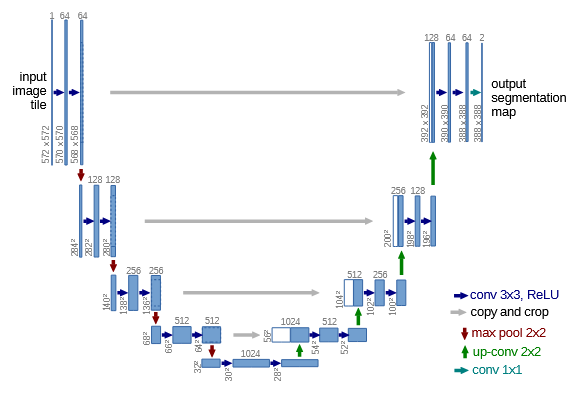
From [U-Net: Convolutional Networks for Biomedical
Image Segmentation]




In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
  # @author: Karim Bekhti
  # the suite of convolution relu convolution relu that constitutes each level of the  Unet
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels,
                      out_channels,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,
                      out_channels,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class Down(nn.Module):
  # @author: Karim Bekhti
  # Operations that downsize the size of the image, increasing the number of channels
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Up(nn.Module):
  # @author: Karim Bekhti
  # Operations that upsize the size of the image, increasing the number of channels
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        x1 = self.up(x1)

        # Handle odd image sizes if needed
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = nn.functional.pad(
            x1,
            [diff_x // 2, diff_x - diff_x // 2,
             diff_y // 2, diff_y - diff_y // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

In [4]:
import torch

class UNet(torch.nn.Module):
  def __init__(self):
    super().__init__()




ModuleNotFoundError: No module named 'diffusion_tf'

In [5]:
!pip install diffusion_tf

ERROR: Could not find a version that satisfies the requirement diffusion_tf (from versions: none)
ERROR: No matching distribution found for diffusion_tf
